# Accidental fall prediction and detection with ensemble method

# Importing packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as ws
ws.filterwarnings("ignore")


# Reading the  data

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/ml_Store/AccidentalFall/cStick_edited.csv')

# checking for missing values and categorical data


In [ ]:
print("Rows :", dataset.shape[0])
print("Columns :", dataset.shape[1])
print()
print("Categorical columns :")
print(dataset.select_dtypes(include=['object']).apply(pd.Series.nunique, axis=0))
print()


Rows : 1409
Columns : 7

Categorical columns :
Series([], dtype: float64)



In [ ]:
print("Description :")
print(dataset.info())
print()
print("missing values:")
print(dataset.isnull().sum())

Description :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Distance       1409 non-null   float64
 1   Pressure       1409 non-null   int64  
 2   HRV            1409 non-null   float64
 3   Sugar level    1409 non-null   float64
 4   SpO2           1409 non-null   float64
 5   Accelerometer  1409 non-null   int64  
 6   Decision       1409 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 77.2 KB
None

missing values:
Distance         0
Pressure         0
HRV              0
Sugar level      0
SpO2             0
Accelerometer    0
Decision         0
dtype: int64


###### display a sample of the dataset

In [ ]:
dataset.sample()

,Distance,Pressure,HRV,Sugar level,SpO2,Accelerometer,Decision
150,60.788,0,76.368,75.58,95.58,0,0


###### display the first five sample of the dataset

In [ ]:
dataset.head()

,Distance,Pressure,HRV,Sugar level,SpO2,Accelerometer,Decision
0,25.540,1,101.396,61.080,87.770,1,1
1,2.595,2,110.190,20.207,65.190,1,2
2,68.067,0,87.412,79.345,99.345,0,0
3,13.090,1,92.266,36.180,81.545,1,1
4,69.430,0,89.480,80.000,99.990,0,0


###### display the last five sample of the dataset

In [ ]:
dataset.tail()

,Distance,Pressure,HRV,Sugar level,SpO2,Accelerometer,Decision
1404,1.155,2,107.310,14.543,62.310,1,0
1405,20.650,1,97.810,51.300,85.325,1,1
1406,65.892,0,84.112,78.220,98.220,0,2
1407,19.120,1,96.688,48.240,84.560,1,1
1408,56.902,0,70.472,73.570,93.570,0,0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Rows and Columns
rows, columns = dataset.shape
print("Rows :", rows)
print("Columns :", columns)


Rows : 1409
Columns : 7


In [ ]:
# Categorical Columns
categorical_columns = dataset.select_dtypes(include=['object']).apply(pd.Series.nunique, axis=0)
print("Categorical columns :")
print(categorical_columns)


Categorical columns :
Series([], dtype: float64)


In [ ]:
# Description
print("\nDescription :")
dataset.info()


Description :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Distance       1409 non-null   float64
 1   Pressure       1409 non-null   int64  
 2   HRV            1409 non-null   float64
 3   Sugar level    1409 non-null   float64
 4   SpO2           1409 non-null   float64
 5   Accelerometer  1409 non-null   int64  
 6   Decision       1409 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 77.2 KB


# Exploring dependent variable

[1 2 0]


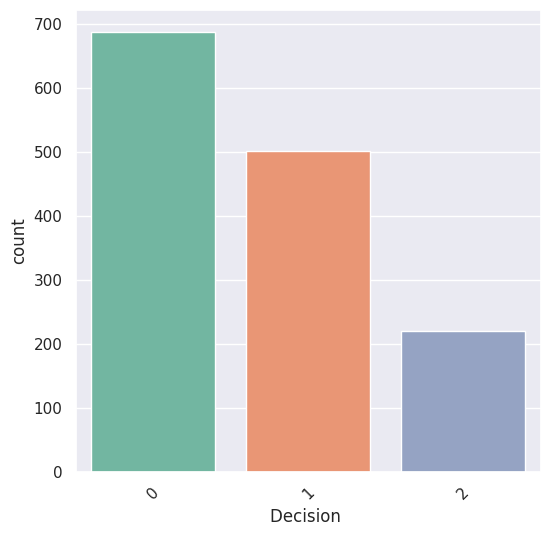

In [ ]:
# Data exploration - print unique values in the last column
print(dataset.iloc[:, -1].unique())

# Set the plot size
plt.figure(figsize=(6, 6))

# Define a color palette with colors for each unique value
color_palette = sns.color_palette("Set2", len(dataset.iloc[:, -1].unique()))

# Create the count plot and specify the color palette
sns.set()
sns.countplot(x=dataset.iloc[:, -1], palette=color_palette)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

[1 2 0]


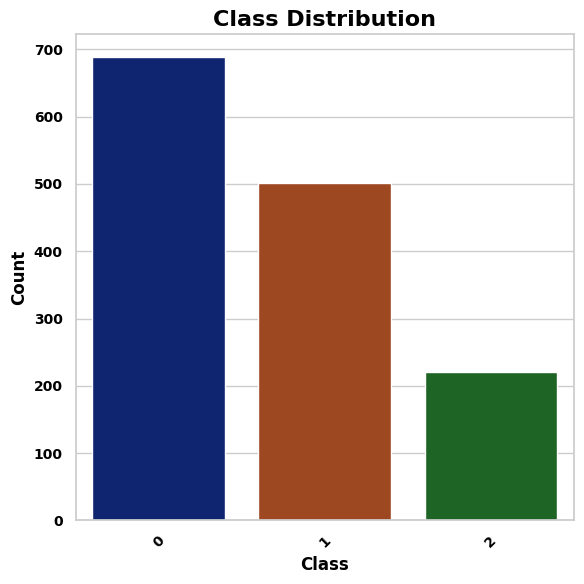

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data exploration - print unique values in the last column
print(dataset.iloc[:, -1].unique())

# Set the plot size
plt.figure(figsize=(6, 6))

# Define a darker color palette
color_palette = sns.color_palette("dark", len(dataset.iloc[:, -1].unique()))

# Set seaborn theme
sns.set(style="whitegrid")

# Create the count plot with darker color palette
ax = sns.countplot(x=dataset.iloc[:, -1], palette=color_palette)

# Set title and axis labels with bold dark font
ax.set_title("Class Distribution", fontsize=16, color='black', fontweight='bold')
ax.set_xlabel("Class", fontsize=12, color='black', fontweight='bold')
ax.set_ylabel("Count", fontsize=12, color='black', fontweight='bold')

# Style tick labels
plt.xticks(rotation=45, fontsize=10, color='black', fontweight='bold')
plt.yticks(fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


[1 2 0]


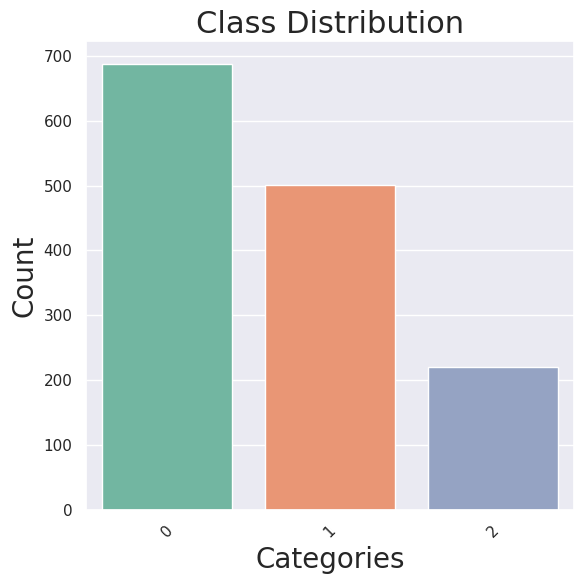

In [ ]:
# Data exploration - print unique values in the last column
print(dataset.iloc[:, -1].unique())

# Set plot-wide font sizes
plt.rcParams.update({
    'axes.titlesize': 16,      # Title font size
    'axes.labelsize': 14,      # Axis label font size
    'xtick.labelsize': 12,     # X-axis tick label font size
    'ytick.labelsize': 12,     # Y-axis tick label font size
})

# Set the plot size
plt.figure(figsize=(6, 6))

# Define a color palette with colors for each unique value
color_palette = sns.color_palette("Set2", len(dataset.iloc[:, -1].unique()))

# Create the count plot and specify the color palette
sns.set()
sns.countplot(x=dataset.iloc[:, -1], palette=color_palette)

plt.xlabel("Categories", fontsize=20)     # Label for x-axis
plt.ylabel("Count", fontsize=20)          # Label for y-axis
plt.title("Class Distribution", fontsize=22)  # Title of the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()       # Adjust layout to prevent overlap
plt.show()


# Correlation amongst Features

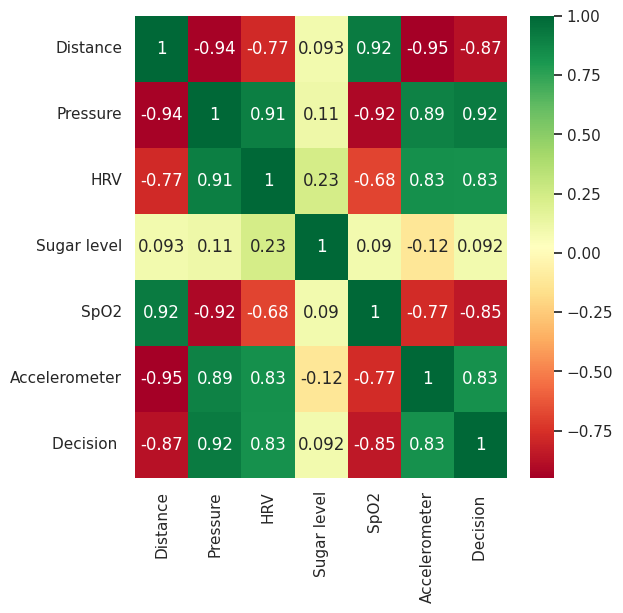

In [ ]:
#CHECKING FOR CORRELATION

corrmat =dataset.corr()
top_corr_features=corrmat.index
plt.figure(figsize=(6,6))
g=sns.heatmap(dataset[top_corr_features].corr(),annot=True, cmap="RdYlGn")

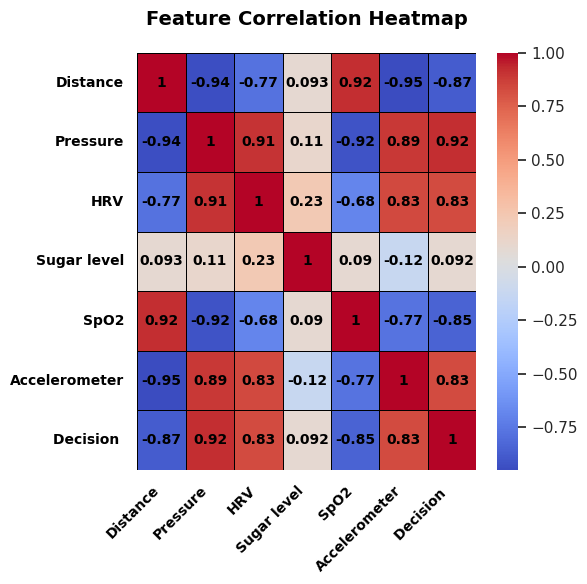

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corrmat = dataset.corr()
top_corr_features = corrmat.index

plt.figure(figsize=(6, 6))

# Create heatmap with darker colormap and styled annotations
g = sns.heatmap(dataset[top_corr_features].corr(),
                annot=True,
                cmap="coolwarm",  # darker, high-contrast colormap
                annot_kws={"size": 10, "weight": "bold", "color": "black"},  # Darker, bold font
                linewidths=0.5,
                linecolor='black')

# Customize tick labels
plt.xticks(rotation=45, ha='right', fontsize=10, color='black', fontweight='bold')
plt.yticks(rotation=0, fontsize=10, color='black', fontweight='bold')

# Optional: Add a title
plt.title("Feature Correlation Heatmap", fontsize=14, color='black', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


# HISTOGRAM TO CHECK FOR GRAPH SHAPE

array([[<Axes: title={'center': 'Distance'}>,
        <Axes: title={'center': 'Pressure'}>,
        <Axes: title={'center': 'HRV'}>],
       [<Axes: title={'center': 'Sugar level'}>,
        <Axes: title={'center': 'SpO2'}>,
        <Axes: title={'center': 'Accelerometer'}>],
       [<Axes: title={'center': 'Decision '}>, <Axes: >, <Axes: >]],
      dtype=object)

<Figure size 2000x2000 with 0 Axes>

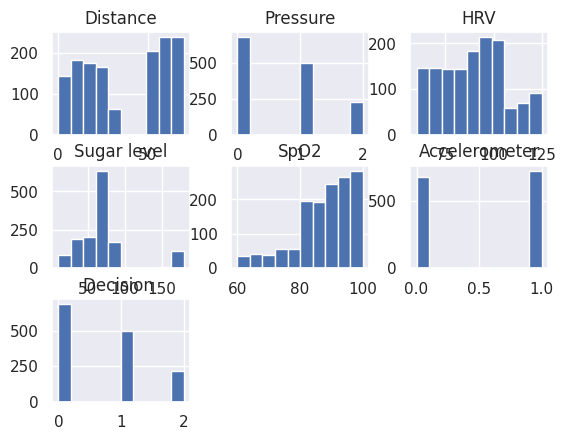

In [ ]:
plt.figure(figsize=(20,20))
dataset.hist()

# splitting to training and test set

In [ ]:

from sklearn.model_selection import train_test_split
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
X_train , X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

# Importing the models needed

In [ ]:
# importing models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
model=[]
model_accuracy=[]

## Decision tree classification

In [ ]:
# Training the Decision Tree Classification model on the Training set
dec = DecisionTreeClassifier(criterion = 'entropy', random_state =42)
# dec = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
model.append('DTC')

dec.fit(X_train, y_train)
y_pred= dec.predict(X_test)
dec_accuracy= accuracy_score(y_pred, y_test)
model_accuracy.append(dec_accuracy)

# Evaluating the DecisionTreeClassifier
print ("Accuracy on test set is ", round(dec.score(X_test, y_test) * 100, 2), "%")
print ("Accuracy on train set is ", round(dec.score(X_train, y_train) * 100, 2), "%")

cm = confusion_matrix(y_pred, y_test)
print(cm)

Accuracy on test set is  92.2 %
Accuracy on train set is  100.0 %
[[124   5   7]
 [  6  93   1]
 [  1   2  43]]


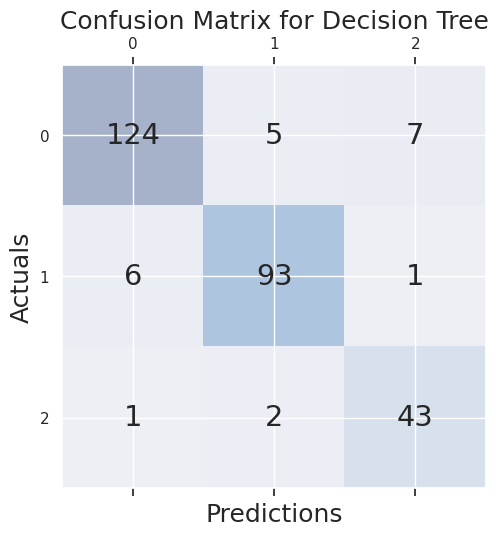

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix for Decision Tree', fontsize=18)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       131
           1       0.93      0.93      0.93       100
           2       0.93      0.84      0.89        51

    accuracy                           0.92       282
   macro avg       0.93      0.91      0.92       282
weighted avg       0.92      0.92      0.92       282



## LogisticRegression

In [ ]:
# Training the LogisticRegression Classification model on the Training set

log = LogisticRegression(random_state = 0)
model.append('LR')

log.fit(X_train, y_train)
y_pred= log.predict(X_test)
log_accuracy= accuracy_score(y_pred, y_test)
model_accuracy.append(log_accuracy)
# Evaluating the Random Forest Model
print ("Accuracy on test set is ", round(log.score(X_test, y_test) * 100, 2), "%")
print ("Accuracy on train set is ", round(log.score(X_train, y_train) * 100, 2), "%")

cm = confusion_matrix(y_pred, y_test)
print(cm)

Accuracy on test set is  96.1 %
Accuracy on train set is  96.27 %
[[128   4   3]
 [  1  95   0]
 [  2   1  48]]


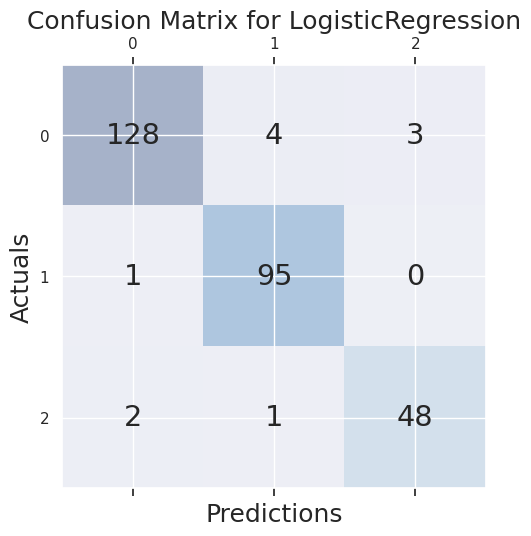

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix for LogisticRegression', fontsize=18)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       131
           1       0.99      0.95      0.97       100
           2       0.94      0.94      0.94        51

    accuracy                           0.96       282
   macro avg       0.96      0.96      0.96       282
weighted avg       0.96      0.96      0.96       282



## Random Forest Classification

In [ ]:
# Training the Random Forest Classification model on the Training set
rfe = RandomForestClassifier(criterion = 'entropy', random_state = 0)
model.append('RFC')

rfe.fit(X_train, y_train)
y_pred= rfe.predict(X_test)
rfe_accuracy= accuracy_score(y_pred, y_test)
model_accuracy.append(rfe_accuracy)
# Evaluating the Random Forest Model
print ("Accuracy on test set is ", round(rfe.score(X_test, y_test) * 100, 2), "%")
print ("Accuracy on train set is ", round(rfe.score(X_train, y_train) * 100, 2), "%")

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy on test set is  92.2 %
Accuracy on train set is  100.0 %
[[124   6   1]
 [  5  93   2]
 [  7   1  43]]


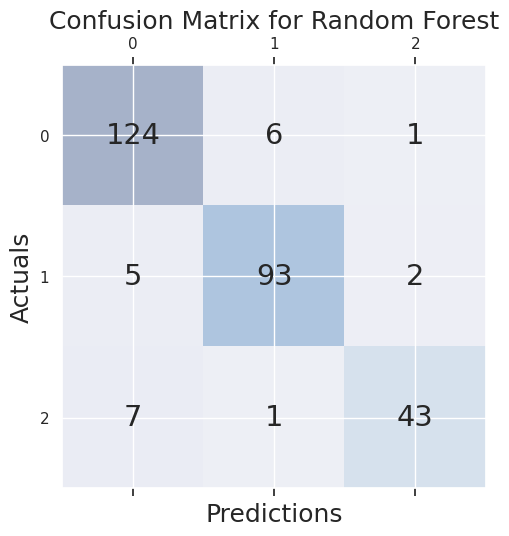

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix for Random Forest', fontsize=18)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       131
           1       0.93      0.93      0.93       100
           2       0.93      0.84      0.89        51

    accuracy                           0.92       282
   macro avg       0.93      0.91      0.92       282
weighted avg       0.92      0.92      0.92       282



## Support Vector Classifer

In [ ]:
# Training the SVM model on the Training set
svc = SVC(kernel = 'linear', random_state = 0)
model.append('SVC')

svc.fit(X_train, y_train)
y_pred= svc.predict(X_test)
svc_accuracy= accuracy_score(y_pred, y_test)
model_accuracy.append(svc_accuracy)

# Evaluating the Random Forest Model
print ("Accuracy on test set is ", round(svc.score(X_test, y_test) * 100, 2), "%")
print ("Accuracy on train set is ", round(svc.score(X_train, y_train) * 100, 2), "%")

cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy on test set is  96.1 %
Accuracy on train set is  96.27 %
[[128   1   2]
 [  4  95   1]
 [  3   0  48]]


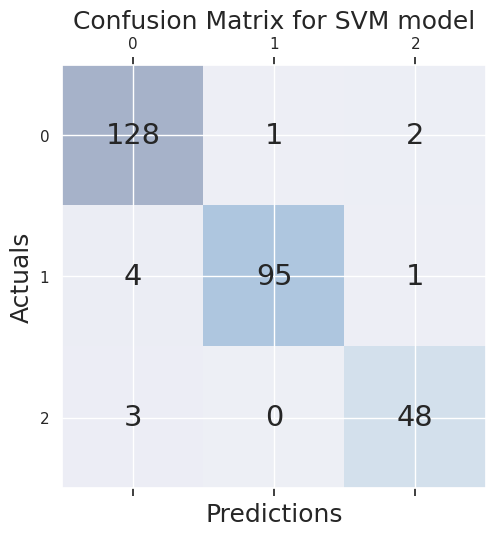

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix for SVM model', fontsize=18)
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       131
           1       0.99      0.95      0.97       100
           2       0.94      0.94      0.94        51

    accuracy                           0.96       282
   macro avg       0.96      0.96      0.96       282
weighted avg       0.96      0.96      0.96       282



## ploting the model and its accuracy on a graph

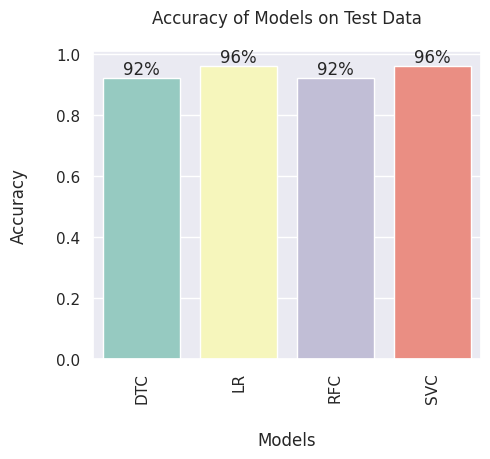

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=model, y=model_accuracy, palette="Set3", ax=ax)
ax.set_title("Accuracy of Models on Test Data", pad=20)
ax.set_xlabel("Models", labelpad=20)
ax.set_ylabel("Accuracy", labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height), (x + width / 2, y + height + 0.01), ha='center')

plt.show()

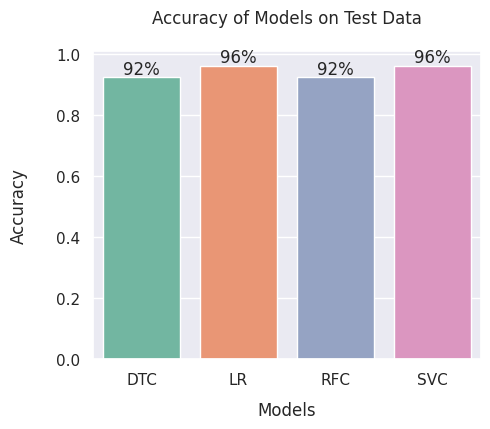

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=model, y=model_accuracy, palette="Set2", ax=ax)

ax.set_title("Accuracy of Models on Test Data", pad=20)
ax.set_xlabel("Models", labelpad=10)
ax.set_ylabel("Accuracy", labelpad=20)

plt.xticks(rotation=0, ha='center')  # Ensure labels are vertically aligned

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height), (x + width / 2, y + height + 0.01), ha='center')

plt.show()


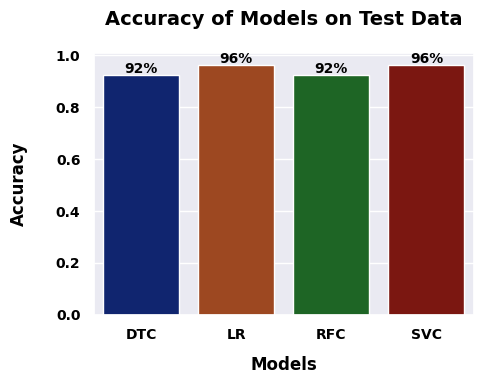

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example data (if not already defined)
# model = ['Model A', 'Model B', 'Model C']
# model_accuracy = [0.85, 0.78, 0.92]

fig, ax = plt.subplots(figsize=(5, 4))

# Use a darker palette
sns.barplot(x=model, y=model_accuracy, palette="dark", ax=ax)

# Set darker and bolder title and labels
ax.set_title("Accuracy of Models on Test Data", pad=20, fontsize=14, color='black', fontweight='bold')
ax.set_xlabel("Models", labelpad=10, fontsize=12, color='black', fontweight='bold')
ax.set_ylabel("Accuracy", labelpad=20, fontsize=12, color='black', fontweight='bold')

plt.xticks(rotation=0, ha='center', color='black', fontsize=10, fontweight='bold')  # X-ticks
plt.yticks(color='black', fontsize=10, fontweight='bold')  # Y-ticks

# Annotate the bars with percentage values
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height), (x + width / 2, y + height + 0.01),
                ha='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


## Bagging Classifier

In [ ]:
# Bagging

bagging_models=[]
bagging_accuracy=[]

models_scores=[]



## Bagging Decision tree

In [ ]:
bag_dec= BaggingClassifier(estimator=dec)
bagging_models.append('Bag_DT')
bag_dec.fit(X_train, y_train)
bag_dec_pred= bag_dec.predict(X_test)
bag_dec_accuracy= accuracy_score(bag_dec_pred, y_test)
bagging_accuracy.append(bag_dec_accuracy)
print("The bagging decisionTree accuracy for the training set is ", bag_dec.score(X_train, y_train))
print("The bagging decisionTree accuracy for the test set is ", bag_dec.score(X_test, y_test))
print("\n")

models_scores.append(['Bagging_DecisionTree', bag_dec_accuracy])



The bagging decisionTree accuracy for the training set is  0.9929015084294588
The bagging decisionTree accuracy for the test set is  0.9326241134751773




## Bagging logistic regression

In [ ]:
bag_log= BaggingClassifier(estimator=log)
bagging_models.append('Bag_LR')

bag_log.fit(X_train, y_train)
bag_log_pred= bag_log.predict(X_test)
bag_log_accuracy= accuracy_score(bag_log_pred, y_test)
bagging_accuracy.append(bag_log_accuracy)
print("The bagging logistic regression accuracy for the training set is ", bag_log.score(X_train, y_train))
print("The bagging logistic regression accuracy for the test set is ", bag_log.score(X_test, y_test))
print("\n")

models_scores.append(['Bagging_DecisionTree', bag_log_accuracy])

The bagging logistic regression accuracy for the training set is  0.9627329192546584
The bagging logistic regression accuracy for the test set is  0.9609929078014184




## Bagging RandomForest

In [ ]:
bag_ref= BaggingClassifier(estimator=rfe)
bagging_models.append('Bag_RFC')

bag_ref.fit(X_train, y_train)

bag_ref_pred= bag_ref.predict(X_test)
bag_ref_accuracy= accuracy_score(bag_ref_pred, y_test)
bagging_accuracy.append(bag_ref_accuracy)
print("The accuracy for bagging RandomForest the training set is ", bag_ref.score(X_train, y_train))
print("The accuracy for bagging RandomForest the test set is ", bag_ref.score(X_test, y_test))

models_scores.append(['Bagging_RandomForest', bag_ref_accuracy])



The accuracy for bagging RandomForest the training set is  0.9680567879325643
The accuracy for bagging RandomForest the test set is  0.9574468085106383


## Bagging SupportVector

In [ ]:
bag_svc= BaggingClassifier(estimator=svc)
bagging_models.append('Bag_SVC')

bag_svc.fit(X_train, y_train)

bag_svc_pred= bag_svc.predict(X_test)
bag_svc_accuracy= accuracy_score(bag_svc_pred, y_test)
bagging_accuracy.append(bag_svc_accuracy)
print("The accuracy for Bagging SupportVector the training set is ", bag_svc.score(X_train, y_train))
print("The accuracy for Bagging SupportVector the test set is ", bag_svc.score(X_test, y_test))

models_scores.append(['Bagging_SupportVector', bag_svc_accuracy])

The accuracy for Bagging SupportVector the training set is  0.9627329192546584
The accuracy for Bagging SupportVector the test set is  0.9609929078014184


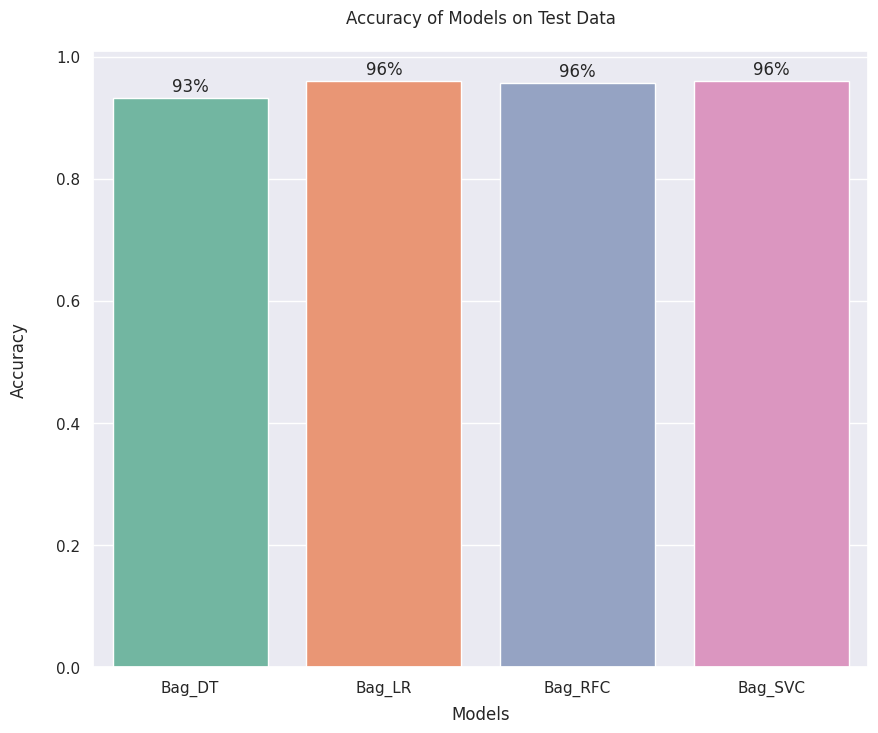

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=bagging_models, y=bagging_accuracy, palette="Set2", ax=ax)
ax.set_title("Accuracy of Models on Test Data", pad=20)
ax.set_xlabel("Models", labelpad=6)
ax.set_ylabel("Accuracy", labelpad=20)
plt.xticks(rotation=0, ha='center')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height), (x + width / 2, y + height + 0.01), ha='center')

plt.show()

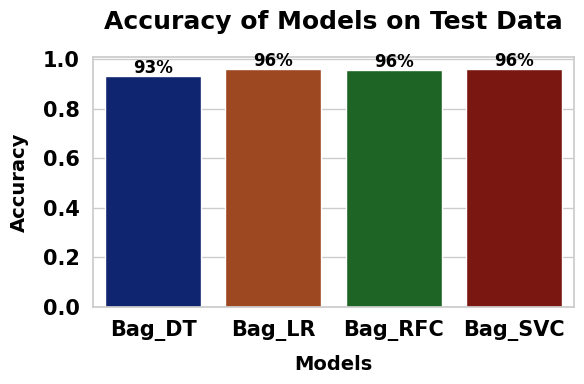

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))

# Use a darker color palette
sns.barplot(x=bagging_models, y=bagging_accuracy, palette="dark", ax=ax)

# Title and axis labels with bold, dark font
ax.set_title("Accuracy of Models on Test Data", fontsize=18, pad=20, color='black', fontweight='bold')
ax.set_xlabel("Models", fontsize=14, labelpad=10, color='black', fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=14, labelpad=10, color='black', fontweight='bold')

# Tick labels styling
plt.xticks(fontsize=15, rotation=0, ha='center', color='black', fontweight='bold')
plt.yticks(fontsize=15, color='black', fontweight='bold')

# Annotate bars with bold, dark text
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(
        '{:.0%}'.format(height),
        (x + width / 2, y + height + 0.01),
        ha='center',
        fontsize=12,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# Boosting Classifier

In [ ]:
# Boosting

boosting_models=[]
boosting_accuracy=[]


## Boosting Decission tree

In [ ]:
#boosting
ada_dec= AdaBoostClassifier(estimator=dec)
boosting_models.append('Boost_DT')
ada_dec.fit(X_train, y_train)
ada_dec_pred= ada_dec.predict(X_test)
boost_dec_accuracy= accuracy_score(ada_dec_pred, y_test)
boosting_accuracy.append(boost_dec_accuracy)
models_scores.append(['Adaboosting_DecisionTree', boost_dec_accuracy])
print("The accuracy for the training set is ", ada_dec.score(X_train, y_train))
print("The accuracy for the test set is ", ada_dec.score(X_test, y_test))


The accuracy for the training set is  1.0
The accuracy for the test set is  0.9219858156028369


## Boosting Logistic regression

In [ ]:
ada_log= AdaBoostClassifier(estimator=log)
boosting_models.append('Boost_LR')
ada_log.fit(X_train, y_train)
ada_log_pred= ada_log.predict(X_test)
boost_log_accuracy= accuracy_score(ada_log_pred, y_test)
boosting_accuracy.append(boost_log_accuracy)
models_scores.append(['Adaboosting_Logistic_regression', boost_log_accuracy])
print("The accuracy for the training set is ", ada_log.score(X_train, y_train))
print("The accuracy for the test set is ", ada_log.score(X_test, y_test))

The accuracy for the training set is  0.9627329192546584
The accuracy for the test set is  0.9609929078014184


## Boosting random forest

In [ ]:
ada_ref= AdaBoostClassifier(estimator=rfe)
boosting_models.append('Boost_RFC')
ada_ref.fit(X_train, y_train)
ada_ref_pred= ada_ref.predict(X_test)
boost_ref_accuracy= accuracy_score(ada_ref_pred, y_test)
boosting_accuracy.append(boost_ref_accuracy)
models_scores.append(['Adaboosting_RandomForest', boost_ref_accuracy])
print("The accuracy for the training set is ", ada_ref.score(X_train, y_train))
print("The accuracy for the test set is ", ada_ref.score(X_test, y_test))


The accuracy for the training set is  1.0
The accuracy for the test set is  0.9219858156028369


## Boosting svc

In [ ]:
ada_svc= AdaBoostClassifier(estimator=svc, algorithm='SAMME')
boosting_models.append('Boost_svc')
ada_svc.fit(X_train, y_train)
ada_svc_pred= ada_svc.predict(X_test)
boost_svc_accuracy= accuracy_score(ada_svc_pred, y_test)
boosting_accuracy.append(boost_svc_accuracy)
models_scores.append(['Adaboosting_SupportVector', boost_svc_accuracy])
print("The accuracy for the training set is ", ada_svc.score(X_train, y_train))
print("The accuracy for the test set is ", ada_svc.score(X_test, y_test))

The accuracy for the training set is  0.9627329192546584
The accuracy for the test set is  0.9609929078014184


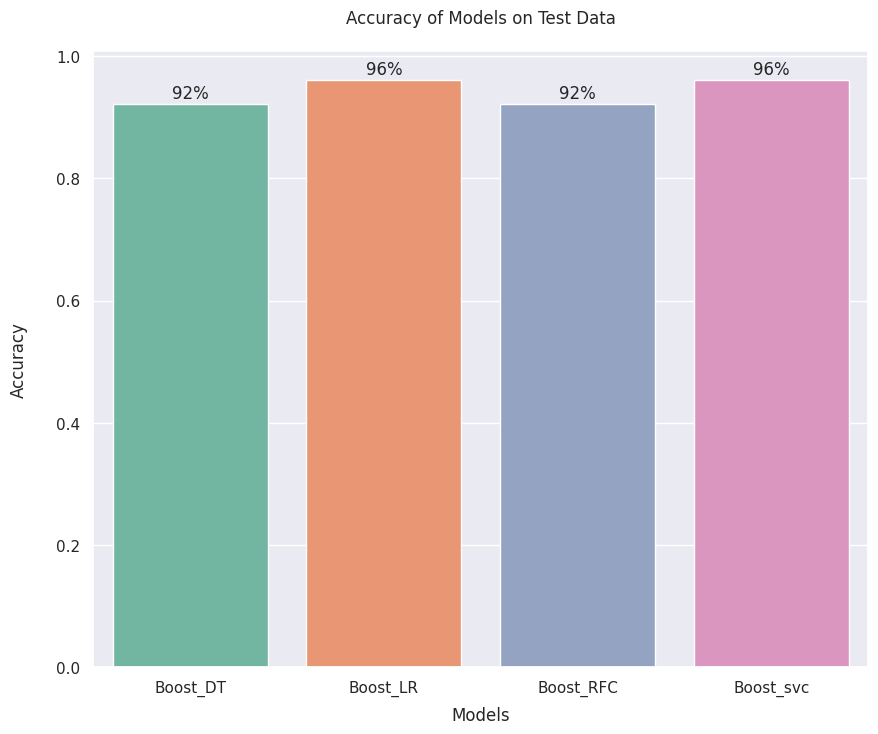

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=boosting_models, y=boosting_accuracy, palette="Set2", ax=ax)
ax.set_title("Accuracy of Models on Test Data", pad=20)
ax.set_xlabel("Models", labelpad=7)
ax.set_ylabel("Accuracy", labelpad=20)
plt.xticks(rotation=0, ha='center')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height), (x + width / 2, y + height + 0.01), ha='center')

plt.show()

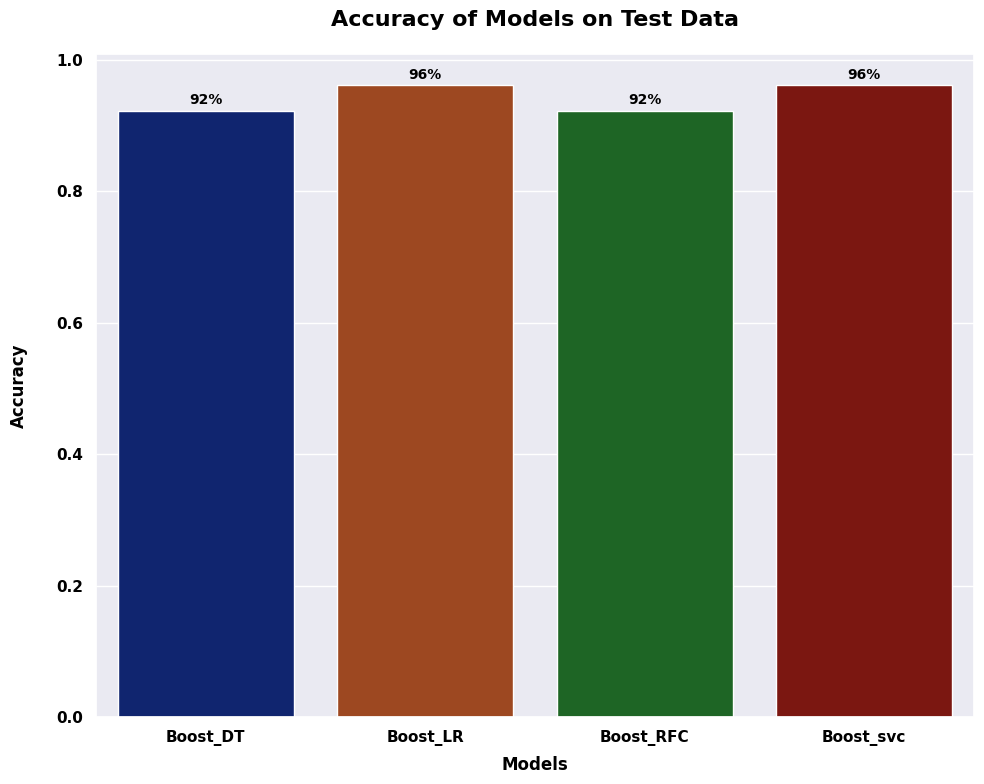

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

# Use a darker, high-contrast palette (you can also define your own list of colors)
sns.barplot(x=boosting_models, y=boosting_accuracy, palette="dark", ax=ax)

# Set darker and bolder title and labels
ax.set_title("Accuracy of Models on Test Data", pad=20, fontsize=16, color='black', fontweight='bold')
ax.set_xlabel("Models", labelpad=7, fontsize=12, color='black', fontweight='bold')
ax.set_ylabel("Accuracy", labelpad=20, fontsize=12, color='black', fontweight='bold')

# Customize x and y ticks
plt.xticks(rotation=0, ha='center', fontsize=11, color='black', fontweight='bold')
plt.yticks(fontsize=11, color='black', fontweight='bold')

# Annotate bars with percentages
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate('{:.0%}'.format(height),
                (x + width / 2, y + height + 0.01),
                ha='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


## Voting Classifier

In [ ]:
estimators=[]

model1= SVC()
estimators.append(("svc", model1))

model2= DecisionTreeClassifier()
estimators.append(("dec", model2))

model3= RandomForestClassifier()
estimators.append(("rad", model3))

model4 = LogisticRegression()
estimators.append(("log", model3))

# create the ensemble model
ensemble = VotingClassifier(estimators, voting="hard")
ensemble.fit(X_train, y_train)

vot_pred= ensemble.predict(X_test)
score_vote= accuracy_score(vot_pred, y_test)
print(score_vote*100)
print("\n")
print("The accuracy for the training set is ", ensemble.score(X_train, y_train))
print("The accuracy for the test set is ", ensemble.score(X_test, y_test))
print("\n")
models_scores.append(['voting classifier', score_vote])


92.19858156028369


The accuracy for the training set is  1.0
The accuracy for the test set is  0.9219858156028369




In [ ]:
import pickle

with open('baggedsvc.pkl', 'wb') as file:
    pickle.dump(bag_svc, file)

In [ ]:
X = dataset.drop(columns=['Distance', 'Pressure', 'HRV', 'Sugar level', 'SpO2', 'Accelerometer'], axis=1)
y = dataset["Decision "]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import Parallel, delayed

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC()
}

# Function to evaluate a single model with k-fold cross-validation
def evaluate_model(model, X, y, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=1))
        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=1))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    return {
        "Model": model.__class__.__name__,
        "K-Folds": k,
        "Accuracy": np.mean(accuracies),
        "Precision": np.mean(precisions),
        "Recall": np.mean(recalls),
        "F1 Score": np.mean(f1_scores)
    }

# Parallelized evaluation for each model and each k
def parallel_evaluation(X, y, classifiers, k_values):
    results = Parallel(n_jobs=-1)(
        delayed(evaluate_model)(clf, X, y, k)
        for name, clf in classifiers.items()
        for k in k_values
    )
    return pd.DataFrame(results)

# Example usage
# Ensure X and y are properly formatted
# Replace this with your actual datase
# X = pd.DataFrame(X)  # Example feature matrix
# y = pd.DataFrame(y)  # Example binary labels

k_values = [2, 5, 10, 20]  # Reduce k for faster debugging
results_df = parallel_evaluation(X, y, classifiers, k_values)

print(results_df)


                     Model  K-Folds  Accuracy  Precision  Recall  F1 Score
0   DecisionTreeClassifier        2       1.0        1.0     1.0       1.0
1   DecisionTreeClassifier        5       1.0        1.0     1.0       1.0
2   DecisionTreeClassifier       10       1.0        1.0     1.0       1.0
3   DecisionTreeClassifier       20       1.0        1.0     1.0       1.0
4   RandomForestClassifier        2       1.0        1.0     1.0       1.0
5   RandomForestClassifier        5       1.0        1.0     1.0       1.0
6   RandomForestClassifier       10       1.0        1.0     1.0       1.0
7   RandomForestClassifier       20       1.0        1.0     1.0       1.0
8       LogisticRegression        2       1.0        1.0     1.0       1.0
9       LogisticRegression        5       1.0        1.0     1.0       1.0
10      LogisticRegression       10       1.0        1.0     1.0       1.0
11      LogisticRegression       20       1.0        1.0     1.0       1.0
12                     SV

In [ ]:
dataset.columns

Index(['Distance', 'Pressure', 'HRV', 'Sugar level', 'SpO2', 'Accelerometer',
       'Decision '],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import Parallel, delayed

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "SVC":SVC()
}

# Function to evaluate a single model with k-fold cross-validation
def evaluate_model(model, X, y, k):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=1))
        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=1))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    return {
        "Model": model.__class__.__name__,
        "K-Folds": k,
        "Accuracy": sum(accuracies) / k,
        "Precision": sum(precisions) / k,
        "Recall": sum(recalls) / k,
        "F1 Score": sum(f1_scores) / k
    }

# Parallelized evaluation for each model and each k
def parallel_evaluation(X, y, classifiers, k_values):
    results = Parallel(n_jobs=-1)(  # Use all available cores
        delayed(evaluate_model)(clf, X, y, k)
        for name, clf in classifiers.items()
        for k in k_values
    )
    return pd.DataFrame(results)

# Example usage with the given classifiers and k values
k_values = [2, 5, 10, 20]
results_df = parallel_evaluation(X.values, y.values, classifiers, k_values)

results_df


,Model,K-Folds,Accuracy,Precision,Recall,F1 Score
0,DecisionTreeClassifier,2,1.0,1.0,1.0,1.0
1,DecisionTreeClassifier,5,1.0,1.0,1.0,1.0
2,DecisionTreeClassifier,10,1.0,1.0,1.0,1.0
3,DecisionTreeClassifier,20,1.0,1.0,1.0,1.0
4,RandomForestClassifier,2,1.0,1.0,1.0,1.0
5,RandomForestClassifier,5,1.0,1.0,1.0,1.0
6,RandomForestClassifier,10,1.0,1.0,1.0,1.0
7,RandomForestClassifier,20,1.0,1.0,1.0,1.0
8,LogisticRegression,2,1.0,1.0,1.0,1.0
9,LogisticRegression,5,1.0,1.0,1.0,1.0


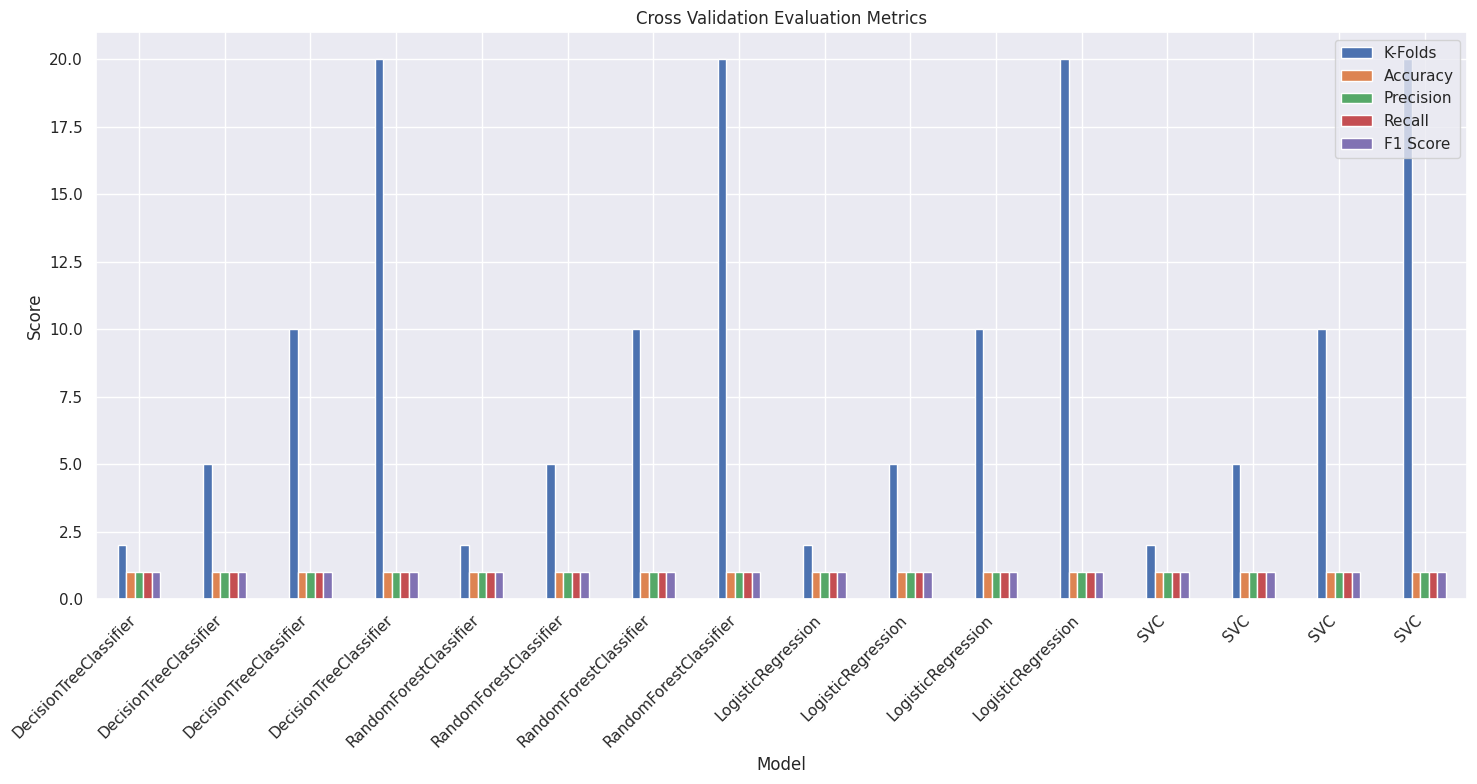

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the metrics dictionaries to DataFrames


# Step 3: Plotting the Evaluation Metrics for Supervised Models
fig, ax = plt.subplots(figsize=(15, 8))
results_df.set_index('Model').plot(kind='bar', ax=ax)
plt.title('Cross Validation Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from imblearn.over_sampling import SMOTE

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.8)

# Apply SMOTE to handle class imbalance (uncomment if needed)
# smote = SMOTE(random_state=42)
# x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Initialize and fit the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf_model = rf.fit(x_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(x_test)
y_pred_rf_proba = rf_model.predict_proba(x_test)

# Calculate and print evaluation metrics
print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision (macro):", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_rf, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred_rf, average='macro'))

# AUC for multiclass: requires `multi_class` parameter
auc_rf = roc_auc_score(y_test, y_pred_rf_proba, multi_class='ovr')
print("AUC (OvR):", auc_rf)


Random Forest Metrics:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
AUC (OvR): 1.0


In [ ]:
# Logistic Regression model
log_reg = LogisticRegression()
log_reg_model = log_reg.fit(x_train, y_train)

# Predict probabilities for the ROC Curve and AUC
y_pred_lr = log_reg_model.predict(x_test)
y_pred_lr_proba = log_reg_model.predict_proba(x_test)

# Evaluation metrics for Logistic Regression
print("\nLogistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision (macro):", precision_score(y_test, y_pred_lr, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_lr, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred_lr, average='macro'))

# AUC for multiclass: requires `multi_class` parameter
auc_lr = roc_auc_score(y_test, y_pred_lr_proba, multi_class='ovr')
print("AUC (OvR):", auc_lr)



Logistic Regression Metrics:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
AUC (OvR): 1.0


In [ ]:
# Decision Tree model
D_tree = DecisionTreeClassifier()
D_tree_model = D_tree.fit(x_train, y_train)

# Predict probabilities for the ROC Curve and AUC
y_pred_DT = D_tree_model.predict(x_test)
y_pred_DT_proba = D_tree_model.predict_proba(x_test)

# Evaluation metrics for Logistic Regression
print("\nDecision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_DT))
print("Precision (macro):", precision_score(y_test, y_pred_DT, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_DT, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred_DT, average='macro'))

# AUC for multiclass: requires `multi_class` parameter
auc_DT = roc_auc_score(y_test, y_pred_DT_proba, multi_class='ovr')
print("AUC (OvR):", auc_DT)



Decision Tree Metrics:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
AUC (OvR): 1.0


In [ ]:
# Logistic Regression model
from sklearn.svm import SVC

SVC = SVC(probability=True)
SVC_model = SVC.fit(x_train, y_train)

# Predict probabilities for the ROC Curve and AUC
y_pred_SVC = SVC_model.predict(x_test)
y_pred_SVC_proba = SVC_model.predict_proba(x_test)

# Evaluation metrics for Support Vector Machine
print("\nSupport Vector Machine Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_SVC))
print("Precision (macro):", precision_score(y_test, y_pred_SVC, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_SVC, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred_SVC, average='macro'))

from sklearn.svm import SVC

# Initialize SVC with probability enabled
svc = SVC(probability=True, random_state=42)
svc.fit(x_train, y_train)

# Use predict_proba for probabilities
y_pred_svc_proba = svc.predict_proba(x_test)

# Example: Calculating AUC
auc_svc = roc_auc_score(y_test, y_pred_svc_proba, multi_class='ovr')
print("AUC (OvR):", auc_svc)

# AUC for multiclass: requires `multi_class` parameter
auc_SVC = roc_auc_score(y_test, y_pred_SVC_proba, multi_class='ovr')
print("AUC (OvR):", auc_SVC)



Support Vector Machine Metrics:
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
AUC (OvR): 1.0
AUC (OvR): 1.0


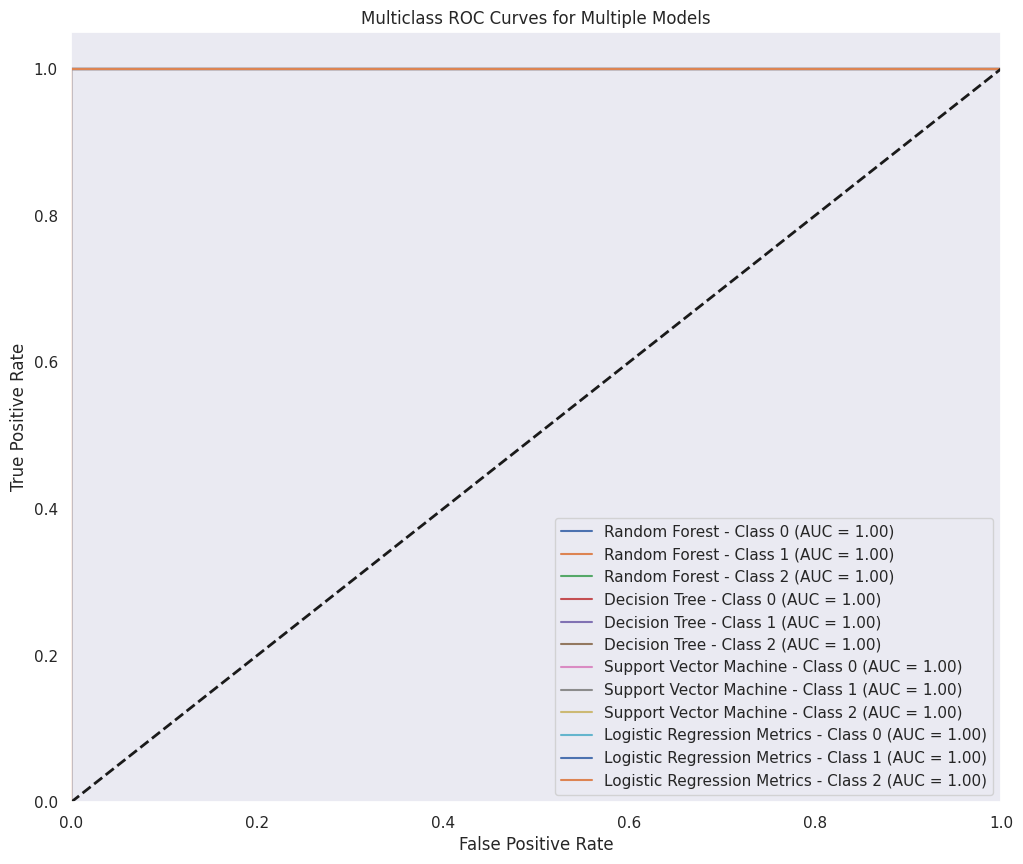

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have the predicted probabilities for each model
# `y_pred_rf_proba`, `y_pred_DT_proba`, `y_pred_svc_proba` are the predicted probabilities
# `y_test` is the true labels

# Binarize the true labels for multiclass ROC
classes = [0, 1, 2]  # Example classes
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Initialize a plot
plt.figure(figsize=(12, 10))

# Dictionary of models and their predicted probabilities
models = {
    "Random Forest": y_pred_rf_proba,
    "Decision Tree": y_pred_DT_proba,
    "Support Vector Machine": y_pred_svc_proba,
    "Logistic Regression Metrics":y_pred_lr_proba

}

# Loop through models and plot ROC curves for each class
for model_name, y_pred_proba in models.items():
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} - Class {classes[i]} (AUC = {roc_auc:.2f})')

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves for Multiple Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()


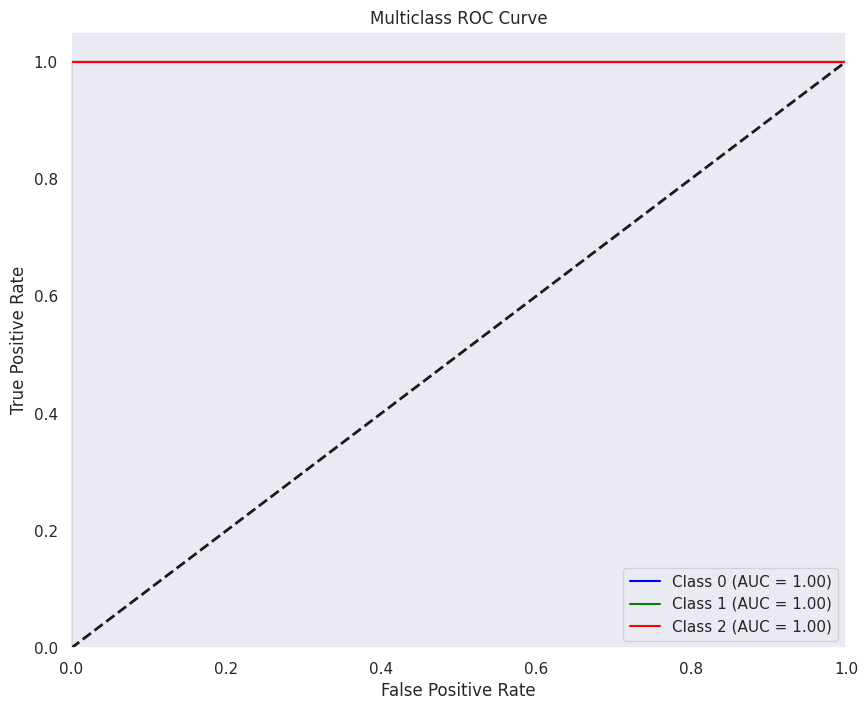

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming `y_test` is the true labels and `y_pred_proba` is the predicted probabilities
# For a classification problem with classes: 0, 1, 2
classes = [0, 1, 2]
y_test_binarized = label_binarize(y_test, classes=classes)  # Binarize true labels
n_classes = len(classes)

# Initialize dictionaries to store FPR, TPR, and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_rf_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming fpr, tpr, and auc values calculated for both models
fpr_DT, tpr_DT, _ = roc_curve(y_test, y_pred_DT_proba)

auc_DT = auc(fpr_DT, tpr_DT)

# Plot ROC curve for Decission Tree
plt.figure(figsize=(8, 6))
plt.plot(fpr_DT, tpr_DT, label=f'Decission Tree (AUC = {auc_DT:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decission Tree')
plt.legend(loc='lower right')
plt.grid()
plt.show()

ValueError: multiclass format is not supported

In [ ]:

# Assuming fpr, tpr, and auc values calculated for both models
fpr_SVC, tpr_lr, _ = roc_curve(y_test, y_pred_SVC_proba)

auc_SVC = auc(fpr_SVC, tpr_SVC)



# Plot ROC curve for Support Vector Machine
plt.figure(figsize=(8, 6))
plt.plot(fpr_SVC, tpr_SVC, label=f'Support Vector Machine (AUC = {auc_SVC:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Support Vector Machine')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have fpr, tpr, and auc values calculated for both models
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)

auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve for Random Forest
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)


auc_lr = auc(fpr_lr, tpr_lr)

# Plot ROC curve for Logistic Regression
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
model = pickle.load(open('baggedsvc.pkl', 'rb'))

In [ ]:
prediction = model.predict([[2.0, 2.0, 2.0, 2.0, 2.0, 2.0]])

In [ ]:
prediction = model.predict([[1.155, 2, 107.310, 14.543, 62.310, 1]])

In [ ]:
print(prediction)